# Basic analysis

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# load csv file
df = pd.read_csv('test_run_20260415_115118.csv')
print(df.head())

   Unnamed: 0  RunId  iteration  Step  width  height  num_agents  rng  \
0           0      0          0   0.0     20      20           5  NaN   
1           1      0          0   1.0     20      20           5  NaN   
2           2      0          0   2.0     20      20           5  NaN   
3           3      0          0   3.0     20      20           5  NaN   
4           4      0          0   4.0     20      20           5  NaN   

   visited_cells  unvisited_cells  max_visited_cell  total_cells  
0              0              400                 0          400  
1              5              395                 1          400  
2             10              390                 1          400  
3             15              385                 1          400  
4             19              381                 2          400  


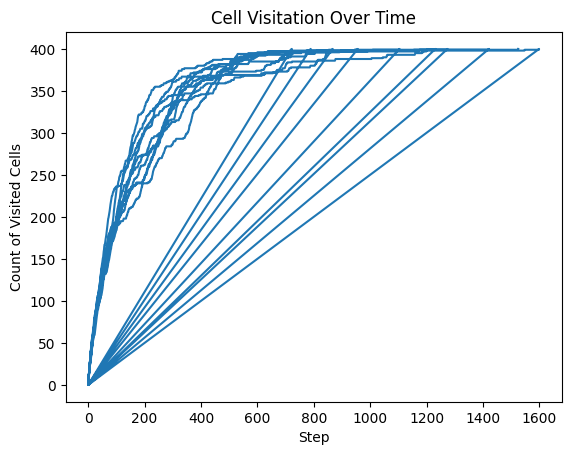

In [15]:
# make a line plot (x axis step, y axis count_visited_cells)
plt.plot(df['Step'], df['visited_cells'])
plt.xlabel('Step')
plt.ylabel('Count of Visited Cells')
plt.title('Cell Visitation Over Time')
plt.show()

# Average over iterations

In [16]:
# aggegate by iteration, everything as avg
df_agg = df.groupby('Step').agg({'visited_cells': 'mean', 'unvisited_cells': 'mean', 'max_visited_cell': 'mean', 'total_cells': 'mean'}).reset_index()

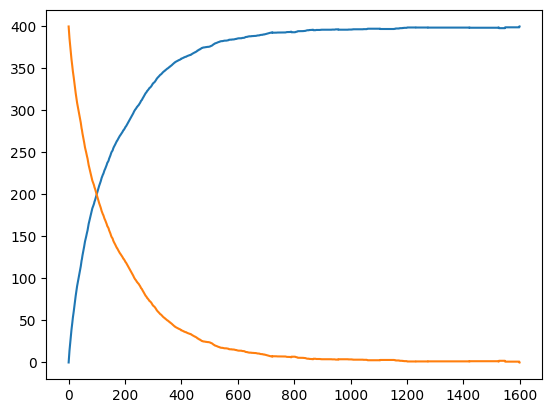

In [17]:
# plot Step/visited_cells
plt.plot(df_agg['Step'], df_agg['visited_cells'])
plt.plot(df_agg['Step'], df_agg['unvisited_cells'])

# Average over iterations for different swarm sizes

In [18]:
# load csv file
df = pd.read_csv('test_run_20260415_115721.csv')
print(df.head())

   Unnamed: 0  RunId  iteration  Step  width  height  num_agents  rng  \
0           0      0          0     0     20      20           5  NaN   
1           1      0          0     1     20      20           5  NaN   
2           2      0          0     2     20      20           5  NaN   
3           3      0          0     3     20      20           5  NaN   
4           4      0          0     4     20      20           5  NaN   

   visited_cells  unvisited_cells  max_visited_cell  total_cells  
0              0              400                 0          400  
1              5              395                 1          400  
2             10              390                 1          400  
3             14              386                 2          400  
4             18              382                 2          400  


In [19]:
# aggegate by num_agents and Step, everything as avg
df_agg = df.groupby(['num_agents', 'Step']).agg({'visited_cells': 'mean', 'unvisited_cells': 'mean', 'max_visited_cell': 'mean', 'total_cells': 'mean'}).reset_index()

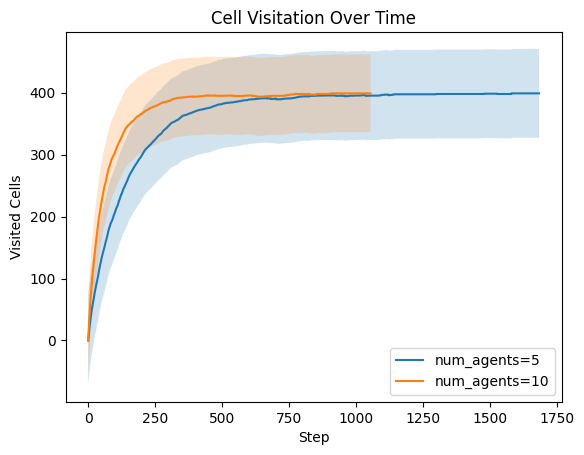

In [21]:
num_agents_list = df_agg['num_agents'].unique()
for num_agents in num_agents_list:
    df_subset = df_agg[df_agg['num_agents'] == num_agents]
    plt.plot(df_subset['Step'], df_subset['visited_cells'], label=f'num_agents={num_agents}')
    # add sd as shaded area
    plt.fill_between(df_subset['Step'], df_subset['visited_cells'] - df_subset['visited_cells'].std(), df_subset['visited_cells'] + df_subset['visited_cells'].std(), alpha=0.2)
plt.legend()
plt.xlabel('Step')
plt.ylabel('Visited Cells')
plt.title('Cell Visitation Over Time')
plt.show()